In [1]:
# Cell 1: Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [2]:
# Cell 2: Đọc dữ liệu sạch
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

print("Kích thước dữ liệu:", df.shape)
display(df.head())

Kích thước dữ liệu: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Cell 3: Mã hóa biến mục tiêu
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [4]:
# Cell 4: Tách X và y
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)

Kích thước X: (7032, 19)
Kích thước y: (7032,)


In [5]:
# Cell 5: Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 19)
X_test : (1407, 19)
y_train: (5625,)
y_test : (1407,)


In [6]:
# Cell 6: Xác định nhóm biến
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = [col for col in X.columns if col not in numerical_features]

print("Biến số:", numerical_features)
print("Biến phân loại:", categorical_features)

Biến số: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
Biến phân loại: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [8]:
# Cell 7: Preprocessor cho Logistic Regression
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [9]:
# Cell 8: Tạo pipeline Logistic Regression
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=2000,
        class_weight="balanced"
    ))
])

In [10]:
# Cell 9: Huấn luyện mô hình
logreg_model.fit(X_train, y_train)

print("Huấn luyện Logistic Regression thành công.")

Huấn luyện Logistic Regression thành công.


In [11]:
# Cell 10: Dự đoán trên tập test
y_pred = logreg_model.predict(X_test)
y_prob = logreg_model.predict_proba(X_test)[:, 1]

print("Dự đoán xong.")

Dự đoán xong.


In [12]:
# Cell 11: Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

=== Logistic Regression ===
Accuracy : 0.7264
Precision: 0.4909
Recall   : 0.7941
F1-score : 0.6067
ROC-AUC  : 0.8353


In [13]:
# Cell 12: Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



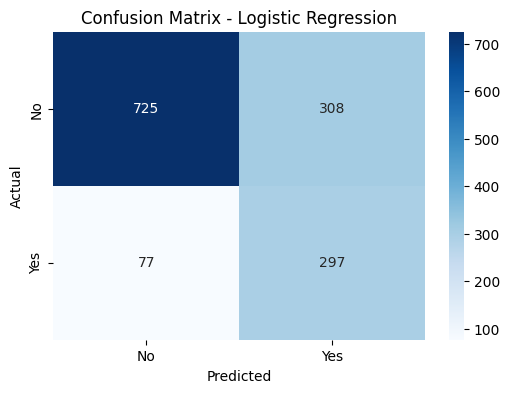

In [14]:
# Cell 13: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No", "Yes"],
            yticklabels=["No", "Yes"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

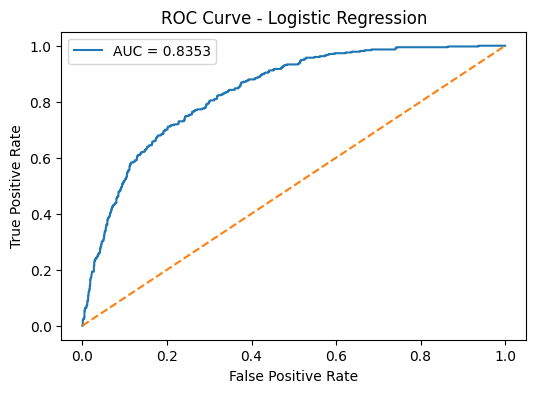

In [15]:
# Cell 14: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [16]:
# Cell 15: Lấy tên feature sau preprocessing
ohe = logreg_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

feature_names = numerical_features + list(encoded_cat_features)

print("Tổng số feature:", len(feature_names))
print(feature_names[:20])

Tổng số feature: 30
['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes']


In [17]:
# Cell 16: Lấy hệ số Logistic Regression
coefficients = logreg_model.named_steps["classifier"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)
display(coef_df.head(10))
display(coef_df.tail(10))

,Feature,Coefficient
10,InternetService_Fiber optic,1.125391
2,TotalCharges,0.610057
28,PaymentMethod_Electronic check,0.418495
21,StreamingTV_Yes,0.382479
23,StreamingMovies_Yes,0.367871
9,MultipleLines_Yes,0.335754
26,PaperlessBilling_Yes,0.258044
27,PaymentMethod_Credit card (automatic),0.079969
3,SeniorCitizen,0.076025
17,DeviceProtection_Yes,0.069509


,Feature,Coefficient
11,InternetService_No,-0.169810
16,DeviceProtection_No internet service,-0.169810
6,Dependents_Yes,-0.227448
19,TechSupport_Yes,-0.309642
13,OnlineSecurity_Yes,-0.350809
7,PhoneService_Yes,-0.374183
1,MonthlyCharges,-0.476384
24,Contract_One year,-0.785572
0,tenure,-1.258362
25,Contract_Two year,-1.445120


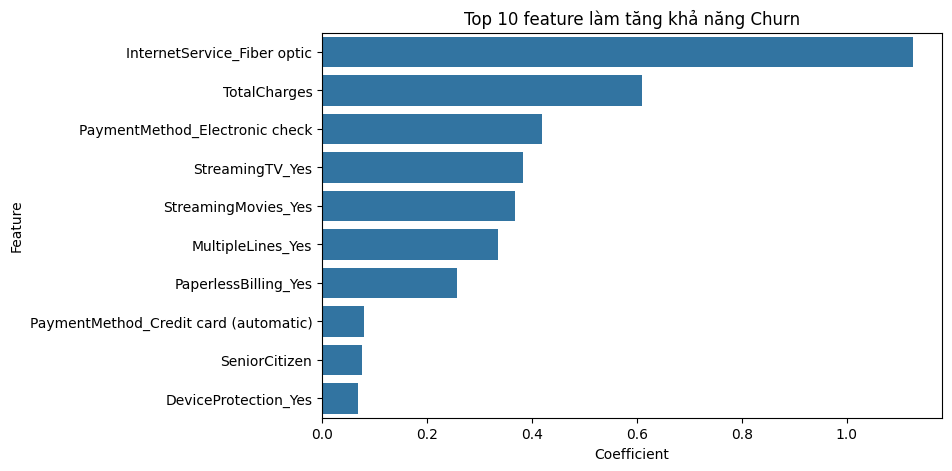

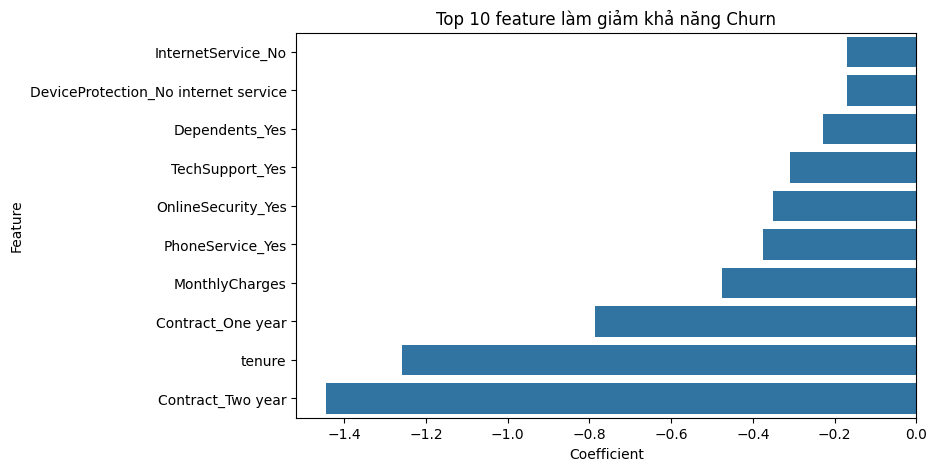

In [18]:
# Cell 17: Vẽ top hệ số ảnh hưởng
top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_positive, x="Coefficient", y="Feature")
plt.title("Top 10 feature làm tăng khả năng Churn")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=top_negative, x="Coefficient", y="Feature")
plt.title("Top 10 feature làm giảm khả năng Churn")
plt.show()

In [19]:
# Cell 18: Logistic Regression không class_weight
logreg_model_plain = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=2000
    ))
])

logreg_model_plain.fit(X_train, y_train)

y_pred_plain = logreg_model_plain.predict(X_test)
y_prob_plain = logreg_model_plain.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (plain) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_plain):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_plain):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_plain):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_plain):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_plain):.4f}")

=== Logistic Regression (plain) ===
Accuracy : 0.8053
Precision: 0.6515
Recall   : 0.5749
F1-score : 0.6108
ROC-AUC  : 0.8361
